#Section 1: Project Setup and Data Preparation

This section imports the required libraries, creates the folder structure for the repository,
loads the raw diabetes dataset, performs basic cleaning, saves cleaned versions of the data, 
and generates initial outputs that will be used in later project sections.

In [2]:
#--------------------------------
#Imported required libraries
#--------------------------------

#Standard Library
import os

#Data handling
import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Statistics
from scipy import stats

#Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression #(Or whatever model you think is best)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("All libraries imported successfully")

All libraries imported successfully


In [3]:
# ----------------------------
# Create repository folder structure
# ----------------------------

data_folder = "data"
outputs_folder = "outputs"
cleaned_data_folder = os.path.join(outputs_folder, "cleaned_data")
figures_folder = os.path.join(outputs_folder, "figures")
tables_folder = os.path.join(outputs_folder, "tables")

try:
    os.makedirs(data_folder, exist_ok=True)
    os.makedirs(outputs_folder, exist_ok=True)
    os.makedirs(cleaned_data_folder, exist_ok=True)
    os.makedirs(figures_folder, exist_ok=True)
    os.makedirs(tables_folder, exist_ok=True)

    print("\nFolder structure is ready.")
    print("Data folder:", data_folder)
    print("Cleaned data folder:", cleaned_data_folder)
    print("Figures folder:", figures_folder)
    print("Tables folder:", tables_folder)

except Exception as e:
    print("ERROR creating folders:", e)


Folder structure is ready.
Data folder: data
Cleaned data folder: outputs\cleaned_data
Figures folder: outputs\figures
Tables folder: outputs\tables


In [4]:
# ----------------------------
# Load the main dataset with error handling
# ----------------------------

file_path = os.path.join(data_folder, "diabetes_012_health_indicators_BRFSS2015.csv")

try:
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Dataset not found at path: {file_path}")

    df = pd.read_csv(file_path)

    print("\nDataset loaded successfully.")
    print("Dataset shape:", df.shape)

except FileNotFoundError as e:
    print("ERROR:", e)
    print("Make sure the dataset is placed inside the 'data/' folder.")

except pd.errors.EmptyDataError:
    print("ERROR: The dataset file is empty.")

except pd.errors.ParserError:
    print("ERROR: There was a problem parsing the CSV file.")

except Exception as e:
    print("An unexpected error occurred while loading the dataset:", e)


Dataset loaded successfully.
Dataset shape: (253680, 22)


In [5]:
# ----------------------------
# Initial inspection
# ----------------------------

try:
    print("\nFirst 5 rows:")
    display(df.head())

    print("\nColumn names:")
    print(df.columns.tolist())

    print("\nData types:")
    display(df.dtypes)

    print("\nMissing values per column:")
    display(df.isnull().sum())

    print("\nNumber of duplicated rows:")
    print(df.duplicated().sum())

except NameError:
    print("ERROR: Dataset was not loaded, so inspection cannot be performed.")


First 5 rows:


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0



Column names:
['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Data types:


Diabetes_012            float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object


Missing values per column:


Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


Number of duplicated rows:
23899


In [6]:
# ----------------------------
# Rename columns for readability
# ----------------------------

rename_map = {
    "Diabetes_012": "DiabetesStatus",
    "HighBP": "HighBloodPressure",
    "HighChol": "HighCholesterol",
    "CholCheck": "CholesterolCheck",
    "BMI": "BMI",
    "Smoker": "Smoker",
    "Stroke": "Stroke",
    "HeartDiseaseorAttack": "HeartDiseaseOrAttack",
    "PhysActivity": "PhysicalActivity",
    "Fruits": "Fruits",
    "Veggies": "Veggies",
    "HvyAlcoholConsump": "HeavyAlcoholConsumption",
    "AnyHealthcare": "AnyHealthcare",
    "NoDocbcCost": "NoDoctorBecauseCost",
    "GenHlth": "GeneralHealth",
    "MentHlth": "MentalHealthDays",
    "PhysHlth": "PhysicalHealthDays",
    "DiffWalk": "DifficultyWalking",
    "Sex": "Sex",
    "Age": "Age",
    "Education": "Education",
    "Income": "Income"
}

try:
    df = df.rename(columns=rename_map)
    print("\nColumns renamed successfully.")
    print(df.columns.tolist())

except NameError:
    print("ERROR: Dataset was not loaded, so columns cannot be renamed.")


Columns renamed successfully.
['DiabetesStatus', 'HighBloodPressure', 'HighCholesterol', 'CholesterolCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseOrAttack', 'PhysicalActivity', 'Fruits', 'Veggies', 'HeavyAlcoholConsumption', 'AnyHealthcare', 'NoDoctorBecauseCost', 'GeneralHealth', 'MentalHealthDays', 'PhysicalHealthDays', 'DifficultyWalking', 'Sex', 'Age', 'Education', 'Income']


In [7]:
# ----------------------------
# Basic cleaning
# ----------------------------

try:
    duplicates_before = df.duplicated().sum()
    print("\nDuplicate rows before removal:", duplicates_before)

    df = df.drop_duplicates()

    duplicates_after = df.duplicated().sum()
    print("Duplicate rows after removal:", duplicates_after)

    print("\nMissing values after cleaning:")
    display(df.isnull().sum())

    print("\nCleaned dataset shape:", df.shape)

except NameError:
    print("ERROR: Dataset was not loaded, so cleaning cannot be performed.")


Duplicate rows before removal: 23899
Duplicate rows after removal: 0

Missing values after cleaning:


DiabetesStatus             0
HighBloodPressure          0
HighCholesterol            0
CholesterolCheck           0
BMI                        0
Smoker                     0
Stroke                     0
HeartDiseaseOrAttack       0
PhysicalActivity           0
Fruits                     0
Veggies                    0
HeavyAlcoholConsumption    0
AnyHealthcare              0
NoDoctorBecauseCost        0
GeneralHealth              0
MentalHealthDays           0
PhysicalHealthDays         0
DifficultyWalking          0
Sex                        0
Age                        0
Education                  0
Income                     0
dtype: int64


Cleaned dataset shape: (229781, 22)


In [8]:
# ----------------------------
# Optional dataset check function
# ----------------------------

def check_dataframe(dataframe):
    print("\nChecking dataset...")
    print("Shape:", dataframe.shape)
    print("Total missing values:", dataframe.isnull().sum().sum())
    print("Duplicate rows:", dataframe.duplicated().sum())
    print("Check complete.")

try:
    check_dataframe(df)

except NameError:
    print("ERROR: Dataset was not loaded, so dataframe checks cannot be performed.")


Checking dataset...
Shape: (229781, 22)
Total missing values: 0
Duplicate rows: 0
Check complete.


In [9]:
# ----------------------------
# Baseline descriptive statistics
# ----------------------------

try:
    print("\nSummary statistics:")
    display(df.describe())

    print("\nDiabetes status counts:")
    display(df["DiabetesStatus"].value_counts().sort_index())

    print("\nMean BMI by diabetes status:")
    display(df.groupby("DiabetesStatus")["BMI"].mean())

    print("\nMean Physical Activity by diabetes status:")
    display(df.groupby("DiabetesStatus")["PhysicalActivity"].mean())

    print("\nMean High Blood Pressure by diabetes status:")
    display(df.groupby("DiabetesStatus")["HighBloodPressure"].mean())

    print("\nMean High Cholesterol by diabetes status:")
    display(df.groupby("DiabetesStatus")["HighCholesterol"].mean())

except NameError:
    print("ERROR: Dataset was not loaded, so descriptive statistics cannot be calculated.")

except KeyError as e:
    print("ERROR: A needed column was not found:", e)



Summary statistics:


,DiabetesStatus,HighBloodPressure,HighCholesterol,CholesterolCheck,BMI,Smoker,Stroke,HeartDiseaseOrAttack,PhysicalActivity,Fruits,Veggies,HeavyAlcoholConsumption,AnyHealthcare,NoDoctorBecauseCost,GeneralHealth,MentalHealthDays,PhysicalHealthDays,DifficultyWalking,Sex,Age,Education,Income
count,229781.000000,229781.000000,229781.000000,229781.000000,229781.00000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000
mean,0.325627,0.454441,0.441760,0.959535,28.68567,0.465661,0.044756,0.103216,0.733355,0.612966,0.794813,0.060710,0.946075,0.092810,2.601151,3.505373,4.675178,0.185507,0.439231,8.086582,4.980568,5.890383
std,0.724623,0.497921,0.496598,0.197047,6.78636,0.498821,0.206767,0.304241,0.442206,0.487073,0.403839,0.238798,0.225871,0.290167,1.064685,7.713725,9.046568,0.388709,0.496295,3.093809,0.992895,2.092477
min,0.000000,0.000000,0.000000,0.000000,12.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.00000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,6.000000
75%,0.000000,1.000000,1.000000,1.000000,32.00000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,4.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000



Diabetes status counts:


DiabetesStatus
0.0    190055
1.0      4629
2.0     35097
Name: count, dtype: int64


Mean BMI by diabetes status:


...

DiabetesStatus
0.0    0.754055
1.0    0.678332
2.0    0.628515
Name: PhysicalActivity, dtype: float64


Mean High Blood Pressure by diabetes status:


DiabetesStatus
0.0    0.395175
1.0    0.629078
2.0    0.752344
Name: HighBloodPressure, dtype: float64


Mean High Cholesterol by diabetes status:


DiabetesStatus
0.0    0.395349
1.0    0.620868
2.0    0.669459
Name: HighCholesterol, dtype: float64

In [10]:
# ----------------------------
# Save the main cleaned dataset
# ----------------------------

cleaned_main_file = os.path.join(cleaned_data_folder, "diabetes_cleaned.csv")

try:
    df.to_csv(cleaned_main_file, index=False)
    print("\nMain cleaned dataset saved successfully.")
    print("Saved to:", cleaned_main_file)

except NameError:
    print("ERROR: Dataset was not loaded, so cleaned data could not be saved.")

except Exception as e:
    print("ERROR saving cleaned dataset:", e)


Main cleaned dataset saved successfully.
Saved to: outputs\cleaned_data\diabetes_cleaned.csv


In [11]:
# ----------------------------
# Save a baseline summary table
# ----------------------------

try:
    summary_table = df.groupby("DiabetesStatus")[["BMI", "PhysicalActivity", "HighBloodPressure", "HighCholesterol"]].mean()
    summary_table_file = os.path.join(tables_folder, "baseline_summary_by_diabetes_status.csv")

    summary_table.to_csv(summary_table_file)

    print("\nBaseline summary table saved successfully.")
    print("Saved to:", summary_table_file)
    display(summary_table)

except NameError:
    print("ERROR: Dataset was not loaded, so the summary table could not be created.")

except KeyError as e:
    print("ERROR: A needed column was not found:", e)


Baseline summary table saved successfully.
Saved to: outputs\tables\baseline_summary_by_diabetes_status.csv


,BMI,PhysicalActivity,HighBloodPressure,HighCholesterol
DiabetesStatus,,,,
0.0,28.030528,0.754055,0.395175,0.395349
1.0,30.726075,0.678332,0.629078,0.620868
2.0,31.964242,0.628515,0.752344,0.669459


In [12]:
# ----------------------------
# Final repository file check
# ----------------------------

try:
    print("\nFiles currently in cleaned_data folder:")
    print(os.listdir(cleaned_data_folder))

    print("\nFiles currently in figures folder:")
    print(os.listdir(figures_folder))

    print("\nFiles currently in tables folder:")
    print(os.listdir(tables_folder))

except Exception as e:
    print("ERROR checking output folders:", e)


Files currently in cleaned_data folder:
['diabetes_cleaned.csv']

Files currently in figures folder:
[]

Files currently in tables folder:
['baseline_summary_by_diabetes_status.csv']


# Section 2: Exploratory Data Analysis and Visualizations

After cleaning the Diabetes Health Indicators dataset, this section explores the data to better understand the main patterns before running statistical tests or machine learning models.

The goal of this section is to examine how diabetes status relates to health, lifestyle, and demographic variables. This connects directly to our project questions about BMI, physical activity, smoking, high blood pressure, high cholesterol, age, income, education, and diabetes risk.

In this section, we use `pandas`, `matplotlib`, and `seaborn` to:

- Summarize the cleaned dataset
- View the distribution of diabetes status
- Compare BMI across diabetes groups
- Examine health factors such as smoking, physical activity, blood pressure, cholesterol, and heart disease
- Explore demographic patterns involving age, sex, income, and education
- Create a correlation heatmap to identify relationships between variables
- Save important visuals and summary tables for later use in the final report and presentation

In [13]:
# ============================================================
# Section 2: Exploratory Data Analysis and Visualizations
# ============================================================

print("SECTION 2: EXPLORATORY DATA ANALYSIS")
print("-" * 50)

# Set visual style
sns.set_theme(style="whitegrid")

print("Dataset shape:", df.shape)

print("Summary statistics:")
display(df.describe())

SECTION 2: EXPLORATORY DATA ANALYSIS
--------------------------------------------------
Dataset shape: (229781, 22)
Summary statistics:


,DiabetesStatus,HighBloodPressure,HighCholesterol,CholesterolCheck,BMI,Smoker,Stroke,HeartDiseaseOrAttack,PhysicalActivity,Fruits,Veggies,HeavyAlcoholConsumption,AnyHealthcare,NoDoctorBecauseCost,GeneralHealth,MentalHealthDays,PhysicalHealthDays,DifficultyWalking,Sex,Age,Education,Income
count,229781.000000,229781.000000,229781.000000,229781.000000,229781.00000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000
mean,0.325627,0.454441,0.441760,0.959535,28.68567,0.465661,0.044756,0.103216,0.733355,0.612966,0.794813,0.060710,0.946075,0.092810,2.601151,3.505373,4.675178,0.185507,0.439231,8.086582,4.980568,5.890383
std,0.724623,0.497921,0.496598,0.197047,6.78636,0.498821,0.206767,0.304241,0.442206,0.487073,0.403839,0.238798,0.225871,0.290167,1.064685,7.713725,9.046568,0.388709,0.496295,3.093809,0.992895,2.092477
min,0.000000,0.000000,0.000000,0.000000,12.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.00000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,6.000000
75%,0.000000,1.000000,1.000000,1.000000,32.00000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,4.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


Diabetes Status Counts:


DiabetesStatus
0.0    190055
1.0      4629
2.0     35097
Name: count, dtype: int64

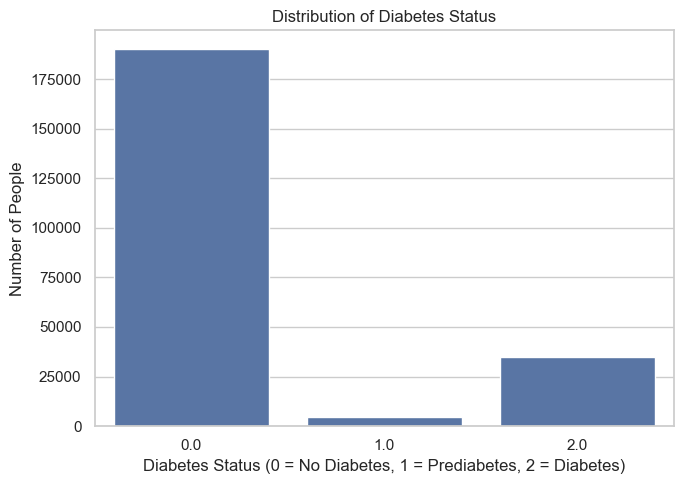

In [14]:
# ----------------------------
# Diabetes status distribution
# ----------------------------

diabetes_counts = df["DiabetesStatus"].value_counts().sort_index()

print("Diabetes Status Counts:")
display(diabetes_counts)

plt.figure(figsize=(7, 5))
sns.countplot(x="DiabetesStatus", data=df)

plt.title("Distribution of Diabetes Status")
plt.xlabel("Diabetes Status (0 = No Diabetes, 1 = Prediabetes, 2 = Diabetes)")
plt.ylabel("Number of People")

plt.tight_layout()
plt.savefig(os.path.join(figures_folder, "diabetes_status_distribution.png"))
plt.show()

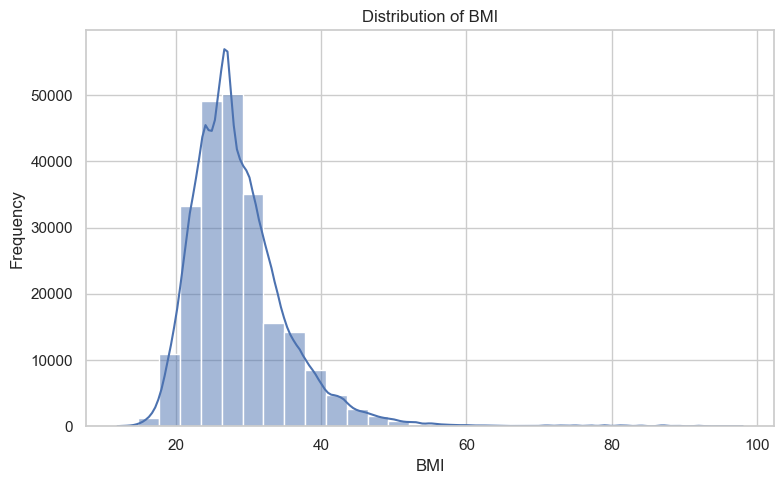

In [15]:
# ----------------------------
# BMI distribution
# ----------------------------

plt.figure(figsize=(8, 5))
sns.histplot(df["BMI"], bins=30, kde=True)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig(os.path.join(figures_folder, "bmi_distribution.png"))
plt.show()

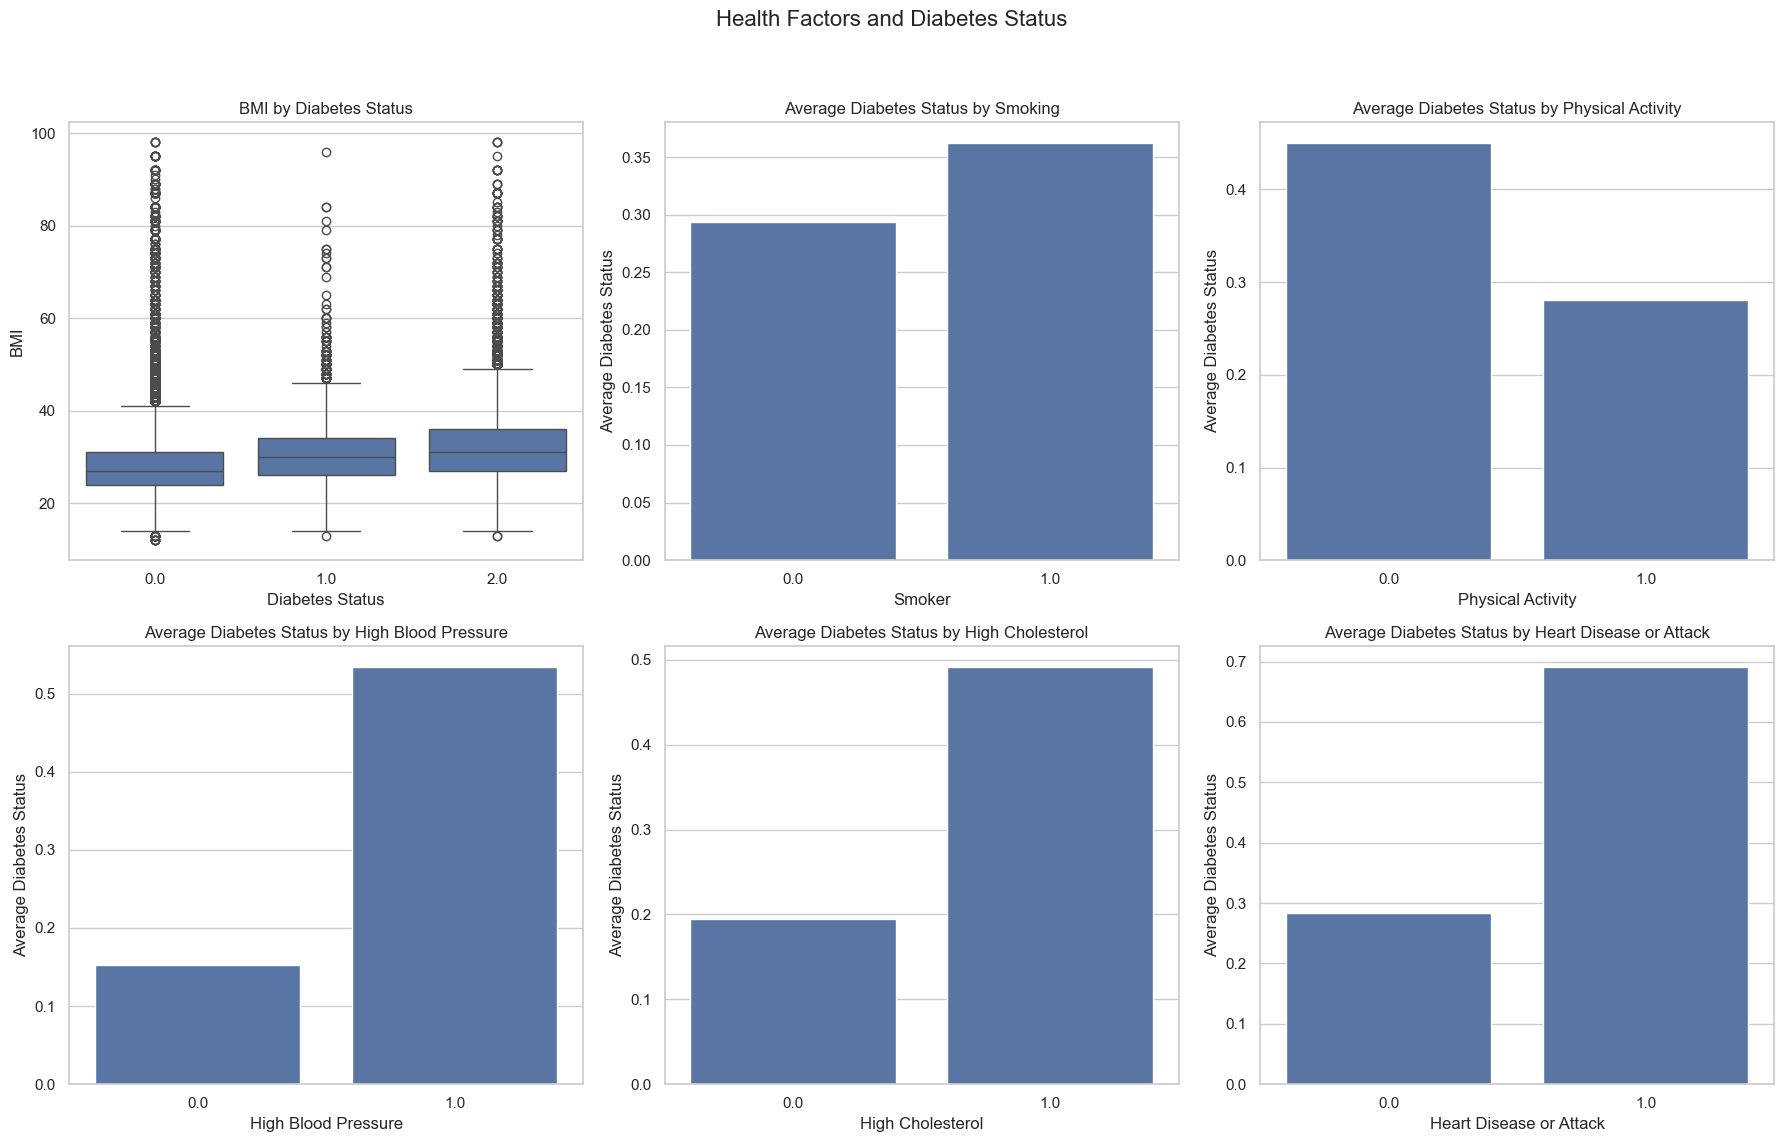

In [16]:
# ----------------------------
# Health factors and diabetes status
# ----------------------------

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Health Factors and Diabetes Status", fontsize=16)

sns.boxplot(data=df, x="DiabetesStatus", y="BMI", ax=axes[0, 0])
axes[0, 0].set_title("BMI by Diabetes Status")
axes[0, 0].set_xlabel("Diabetes Status")
axes[0, 0].set_ylabel("BMI")

sns.barplot(data=df, x="Smoker", y="DiabetesStatus", ax=axes[0, 1], errorbar=None)
axes[0, 1].set_title("Average Diabetes Status by Smoking")
axes[0, 1].set_xlabel("Smoker")
axes[0, 1].set_ylabel("Average Diabetes Status")

sns.barplot(data=df, x="PhysicalActivity", y="DiabetesStatus", ax=axes[0, 2], errorbar=None)
axes[0, 2].set_title("Average Diabetes Status by Physical Activity")
axes[0, 2].set_xlabel("Physical Activity")
axes[0, 2].set_ylabel("Average Diabetes Status")

sns.barplot(data=df, x="HighBloodPressure", y="DiabetesStatus", ax=axes[1, 0], errorbar=None)
axes[1, 0].set_title("Average Diabetes Status by High Blood Pressure")
axes[1, 0].set_xlabel("High Blood Pressure")
axes[1, 0].set_ylabel("Average Diabetes Status")

sns.barplot(data=df, x="HighCholesterol", y="DiabetesStatus", ax=axes[1, 1], errorbar=None)
axes[1, 1].set_title("Average Diabetes Status by High Cholesterol")
axes[1, 1].set_xlabel("High Cholesterol")
axes[1, 1].set_ylabel("Average Diabetes Status")

sns.barplot(data=df, x="HeartDiseaseOrAttack", y="DiabetesStatus", ax=axes[1, 2], errorbar=None)
axes[1, 2].set_title("Average Diabetes Status by Heart Disease or Attack")
axes[1, 2].set_xlabel("Heart Disease or Attack")
axes[1, 2].set_ylabel("Average Diabetes Status")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(figures_folder, "health_factors_diabetes.png"))
plt.show()

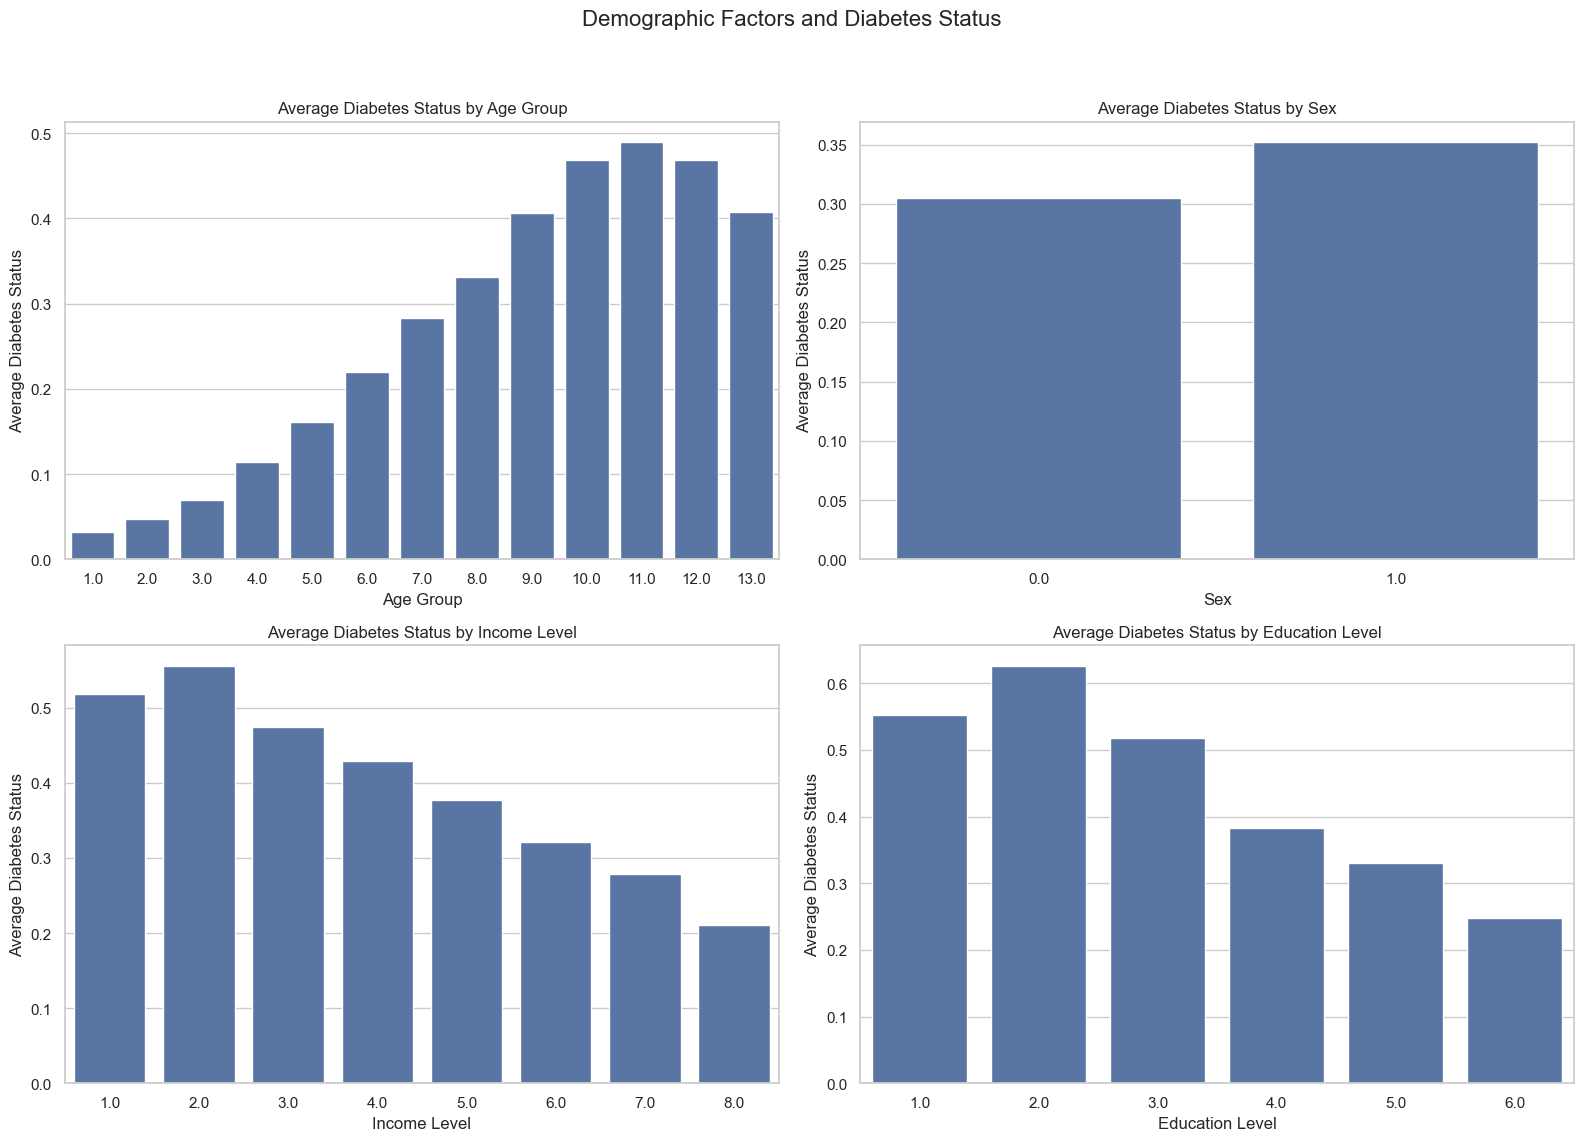

In [17]:
# ----------------------------
# Demographic factors and diabetes status
# ----------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Demographic Factors and Diabetes Status", fontsize=16)

sns.barplot(data=df, x="Age", y="DiabetesStatus", ax=axes[0, 0], errorbar=None)
axes[0, 0].set_title("Average Diabetes Status by Age Group")
axes[0, 0].set_xlabel("Age Group")
axes[0, 0].set_ylabel("Average Diabetes Status")

sns.barplot(data=df, x="Sex", y="DiabetesStatus", ax=axes[0, 1], errorbar=None)
axes[0, 1].set_title("Average Diabetes Status by Sex")
axes[0, 1].set_xlabel("Sex")
axes[0, 1].set_ylabel("Average Diabetes Status")

sns.barplot(data=df, x="Income", y="DiabetesStatus", ax=axes[1, 0], errorbar=None)
axes[1, 0].set_title("Average Diabetes Status by Income Level")
axes[1, 0].set_xlabel("Income Level")
axes[1, 0].set_ylabel("Average Diabetes Status")

sns.barplot(data=df, x="Education", y="DiabetesStatus", ax=axes[1, 1], errorbar=None)
axes[1, 1].set_title("Average Diabetes Status by Education Level")
axes[1, 1].set_xlabel("Education Level")
axes[1, 1].set_ylabel("Average Diabetes Status")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(figures_folder, "demographic_factors_diabetes.png"))
plt.show()

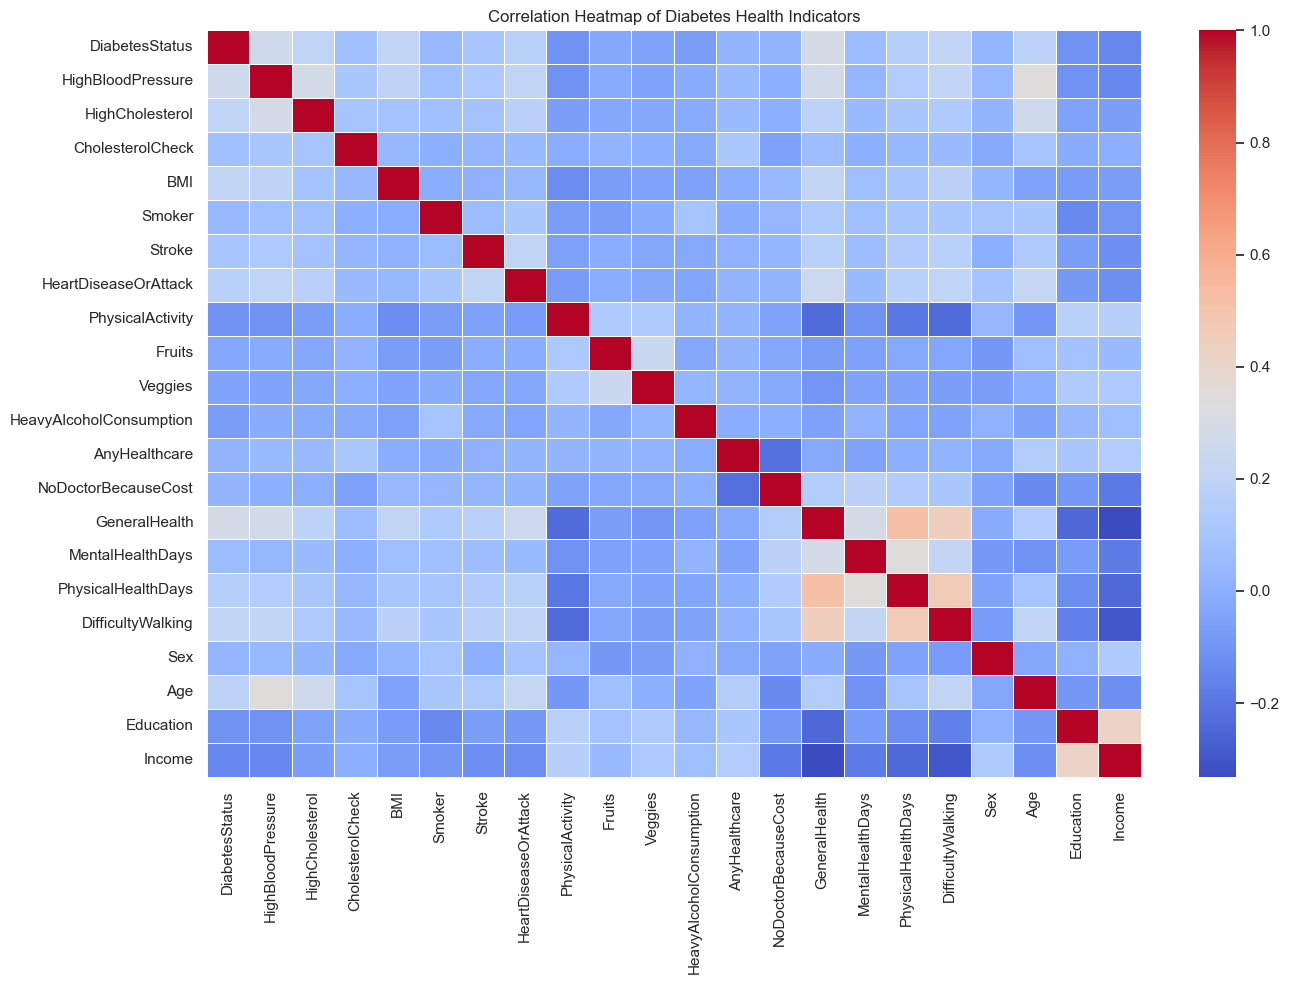

In [18]:
# ----------------------------
# Correlation heatmap
# ----------------------------

correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap of Diabetes Health Indicators")

plt.tight_layout()
plt.savefig(os.path.join(figures_folder, "correlation_heatmap.png"))
plt.show()

In [19]:
# ----------------------------
# Save EDA summary table
# ----------------------------

eda_summary = df.groupby("DiabetesStatus")[
    [
        "BMI",
        "PhysicalActivity",
        "Smoker",
        "HighBloodPressure",
        "HighCholesterol",
        "HeartDiseaseOrAttack",
        "Age",
        "Sex",
        "Income",
        "Education"
    ]
].mean()

eda_summary_file = os.path.join(tables_folder, "eda_summary_by_diabetes_status.csv")
eda_summary.to_csv(eda_summary_file)

print("EDA summary table saved successfully.")
print("Saved to:", eda_summary_file)

display(eda_summary)

EDA summary table saved successfully.
Saved to: outputs\tables\eda_summary_by_diabetes_status.csv


,BMI,PhysicalActivity,Smoker,HighBloodPressure,HighCholesterol,HeartDiseaseOrAttack,Age,Sex,Income,Education
DiabetesStatus,,,,,,,,,,
0.0,28.030528,0.754055,0.455110,0.395175,0.395349,0.079961,7.824230,0.432243,6.031786,5.029823
1.0,30.726075,0.678332,0.492763,0.629078,0.620868,0.143444,9.082091,0.437459,5.350832,4.783971
2.0,31.964242,0.628515,0.519218,0.752344,0.669459,0.223837,9.375958,0.477306,5.195829,4.739778


In [20]:
# ----------------------------
# NumPy usage: Summary statistics
# ----------------------------

try:
    bmi_values = df["BMI"].values

    print("NumPy BMI Mean:", np.mean(bmi_values))
    print("NumPy BMI Median:", np.median(bmi_values))
    print("NumPy BMI Standard Deviation:", np.std(bmi_values))

except Exception as e:
    print("ERROR in NumPy calculations:", e)

NumPy BMI Mean: 28.685670268647105
NumPy BMI Median: 27.0
NumPy BMI Standard Deviation: 6.786345574493759


# Section 3: Statistical Analysis

In this section, we move beyond visual patterns and test whether the observed relationships are statistically significant.

Using the `scipy` library, we perform hypothesis testing to determine whether differences between groups are meaningful or due to random variation.

The main tests performed include:

- Independent t-tests to compare means between groups
- Pearson correlation to measure relationships between variables

These tests help answer our research questions about whether factors such as BMI, physical activity, blood pressure, and cholesterol are significantly associated with diabetes status.

In [28]:
# ============================================================
# Section 3: Statistical Analysis
# ============================================================

print("SECTION 3: STATISTICAL ANALYSIS")
print("-" * 50)


print("Dataset ready for statistical analysis.")
print("Shape:", df.shape)

SECTION 3: STATISTICAL ANALYSIS
--------------------------------------------------
Dataset ready for statistical analysis.
Shape: (229781, 22)


In [29]:
# ----------------------------
# Descriptive statistics by diabetes status
# ----------------------------

stats_summary = df.groupby("DiabetesStatus")[
    [
        "BMI",
        "PhysicalActivity",
        "HighBloodPressure",
        "HighCholesterol"
    ]
].mean()

print("Mean values by diabetes status:")
display(stats_summary)

stats_summary_file = os.path.join(tables_folder, "stats_summary_by_diabetes_status.csv")
stats_summary.to_csv(stats_summary_file)

print("Statistical summary table saved to:", stats_summary_file)

print("""
DiabetesStatus meaning:
0 = No Diabetes
1 = Prediabetes
2 = Diabetes
""")

Mean values by diabetes status:


,BMI,PhysicalActivity,HighBloodPressure,HighCholesterol
DiabetesStatus,,,,
0.0,28.030528,0.754055,0.395175,0.395349
1.0,30.726075,0.678332,0.629078,0.620868
2.0,31.964242,0.628515,0.752344,0.669459


Statistical summary table saved to: outputs\tables\stats_summary_by_diabetes_status.csv

DiabetesStatus meaning:
0 = No Diabetes
1 = Prediabetes
2 = Diabetes



In [30]:
# ----------------------------
# ANOVA Test: BMI across diabetes groups
# ----------------------------

bmi_no_diabetes = df[df["DiabetesStatus"] == 0]["BMI"].values
bmi_prediabetes = df[df["DiabetesStatus"] == 1]["BMI"].values
bmi_diabetes = df[df["DiabetesStatus"] == 2]["BMI"].values

anova_result = stats.f_oneway(
    bmi_no_diabetes,
    bmi_prediabetes,
    bmi_diabetes
)

print("ANOVA TEST: BMI across diabetes groups")
print("Mean BMI - No Diabetes:", np.mean(bmi_no_diabetes))
print("Mean BMI - Prediabetes:", np.mean(bmi_prediabetes))
print("Mean BMI - Diabetes:", np.mean(bmi_diabetes))
print("F-statistic:", anova_result.statistic)
print("P-value:", anova_result.pvalue)

if anova_result.pvalue < 0.05:
    print("Conclusion: BMI is significantly different across diabetes groups.")
else:
    print("Conclusion: BMI is not significantly different across diabetes groups.")

ANOVA TEST: BMI across diabetes groups
Mean BMI - No Diabetes: 28.03052800505117
Mean BMI - Prediabetes: 30.72607474616548
Mean BMI - Diabetes: 31.96424195800211
F-statistic: 5436.169942458786
P-value: 0.0
Conclusion: BMI is significantly different across diabetes groups.


In [31]:
# ----------------------------
# Pearson Correlation: BMI and Diabetes Status
# ----------------------------

bmi_corr, bmi_corr_p = stats.pearsonr(
    df["BMI"],
    df["DiabetesStatus"]
)

print("PEARSON CORRELATION: BMI and Diabetes Status")
print("Correlation coefficient:", bmi_corr)
print("P-value:", bmi_corr_p)

if bmi_corr_p < 0.05:
    print("Conclusion: BMI has a statistically significant relationship with diabetes status.")
else:
    print("Conclusion: BMI does not have a statistically significant relationship with diabetes status.")

PEARSON CORRELATION: BMI and Diabetes Status
Correlation coefficient: 0.2120270211393122
P-value: 0.0
Conclusion: BMI has a statistically significant relationship with diabetes status.


In [32]:
# ----------------------------
# T-Test: Physical Activity and Diabetes Status
# From Abdul's section
# ----------------------------

active_group = df[df["PhysicalActivity"] == 1]["DiabetesStatus"].values
inactive_group = df[df["PhysicalActivity"] == 0]["DiabetesStatus"].values

activity_ttest = stats.ttest_ind(
    active_group,
    inactive_group,
    equal_var=False
)

print("T-TEST: Physical Activity and Diabetes Status")
print("Mean diabetes status - Active:", np.mean(active_group))
print("Mean diabetes status - Inactive:", np.mean(inactive_group))
print("T-statistic:", activity_ttest.statistic)
print("P-value:", activity_ttest.pvalue)

if activity_ttest.pvalue < 0.05:
    print("Conclusion: Active and inactive groups differ significantly in diabetes status.")
else:
    print("Conclusion: No significant difference was found between active and inactive groups.")

T-TEST: Physical Activity and Diabetes Status
Mean diabetes status - Active: 0.2804446000557827
Mean diabetes status - Inactive: 0.4498939121919373
T-statistic: -45.7188998959597
P-value: 0.0
Conclusion: Active and inactive groups differ significantly in diabetes status.


In [33]:
# ----------------------------
# Chi-square helper function
# ----------------------------

def chi_square_analysis(column_name):
    table = pd.crosstab(df[column_name], df["DiabetesStatus"])
    chi2, p_value, dof, expected = stats.chi2_contingency(table)

    print(f"\nCHI-SQUARE TEST: {column_name} and Diabetes Status")
    display(table)

    print("Chi-square statistic:", chi2)
    print("Degrees of freedom:", dof)
    print("P-value:", p_value)

    if p_value < 0.05:
        print(f"Conclusion: {column_name} is significantly associated with diabetes status.")
    else:
        print(f"Conclusion: {column_name} is not significantly associated with diabetes status.")

    return chi2, p_value, dof

In [34]:
# ----------------------------
# Run chi-square tests
# ----------------------------

bp_chi2, bp_p, bp_dof = chi_square_analysis("HighBloodPressure")
chol_chi2, chol_p, chol_dof = chi_square_analysis("HighCholesterol")
smoker_chi2, smoker_p, smoker_dof = chi_square_analysis("Smoker")
heart_chi2, heart_p, heart_dof = chi_square_analysis("HeartDiseaseOrAttack")


CHI-SQUARE TEST: HighBloodPressure and Diabetes Status


DiabetesStatus,0.0,1.0,2.0
HighBloodPressure,,,
0.0,114950,1717,8692
1.0,75105,2912,26405


Chi-square statistic: 15825.17954678162
Degrees of freedom: 2
P-value: 0.0
Conclusion: HighBloodPressure is significantly associated with diabetes status.

CHI-SQUARE TEST: HighCholesterol and Diabetes Status


DiabetesStatus,0.0,1.0,2.0
HighCholesterol,,,
0.0,114917,1755,11601
1.0,75138,2874,23496


Chi-square statistic: 9640.98449350311
Degrees of freedom: 2
P-value: 0.0
Conclusion: HighCholesterol is significantly associated with diabetes status.

CHI-SQUARE TEST: Smoker and Diabetes Status


DiabetesStatus,0.0,1.0,2.0
Smoker,,,
0.0,103559,2348,16874
1.0,86496,2281,18223


Chi-square statistic: 503.28356193301806
Degrees of freedom: 2
P-value: 5.168483211755173e-110
Conclusion: Smoker is significantly associated with diabetes status.

CHI-SQUARE TEST: HeartDiseaseOrAttack and Diabetes Status


DiabetesStatus,0.0,1.0,2.0
HeartDiseaseOrAttack,,,
0.0,174858,3965,27241
1.0,15197,664,7856


Chi-square statistic: 6708.03642156113
Degrees of freedom: 2
P-value: 0.0
Conclusion: HeartDiseaseOrAttack is significantly associated with diabetes status.


In [35]:
# ----------------------------
# Save statistical results
# ----------------------------

statistical_results = pd.DataFrame({
    "Test": [
        "ANOVA",
        "Pearson Correlation",
        "T-Test",
        "Chi-Square",
        "Chi-Square",
        "Chi-Square",
        "Chi-Square"
    ],
    "Variable": [
        "BMI across DiabetesStatus groups",
        "BMI and DiabetesStatus",
        "PhysicalActivity and DiabetesStatus",
        "HighBloodPressure and DiabetesStatus",
        "HighCholesterol and DiabetesStatus",
        "Smoker and DiabetesStatus",
        "HeartDiseaseOrAttack and DiabetesStatus"
    ],
    "Statistic": [
        anova_result.statistic,
        bmi_corr,
        activity_ttest.statistic,
        bp_chi2,
        chol_chi2,
        smoker_chi2,
        heart_chi2
    ],
    "P_Value": [
        anova_result.pvalue,
        bmi_corr_p,
        activity_ttest.pvalue,
        bp_p,
        chol_p,
        smoker_p,
        heart_p
    ],
    "Significant_At_0_05": [
        anova_result.pvalue < 0.05,
        bmi_corr_p < 0.05,
        activity_ttest.pvalue < 0.05,
        bp_p < 0.05,
        chol_p < 0.05,
        smoker_p < 0.05,
        heart_p < 0.05
    ]
})

statistical_results_file = os.path.join(tables_folder, "statistical_results.csv")
statistical_results.to_csv(statistical_results_file, index=False)

print("Statistical results saved successfully.")
print("Saved to:", statistical_results_file)

display(statistical_results)

Statistical results saved successfully.
Saved to: outputs\tables\statistical_results.csv


,Test,Variable,Statistic,P_Value,Significant_At_0_05
0,ANOVA,BMI across DiabetesStatus groups,5436.169942,0.000000e+00,True
1,Pearson Correlation,BMI and DiabetesStatus,0.212027,0.000000e+00,True
2,T-Test,PhysicalActivity and DiabetesStatus,-45.718900,0.000000e+00,True
3,Chi-Square,HighBloodPressure and DiabetesStatus,15825.179547,0.000000e+00,True
4,Chi-Square,HighCholesterol and DiabetesStatus,9640.984494,0.000000e+00,True
5,Chi-Square,Smoker and DiabetesStatus,503.283562,5.168483e-110,True
6,Chi-Square,HeartDiseaseOrAttack and DiabetesStatus,6708.036422,0.000000e+00,True
